# Perturbed waveform

Claudi Vall Müller - University of Amsterdam.

Last modified: 27.05.2026

_Goal of the code:_ 

Obtain and understand the waveform when perturbing a monochromatic/chirping gravitational wave signal with a time-dependent Doppler effect. 


_Main outcome:_

Waveforms $h(u)$ and their Fourier transforms $\tilde{h}(f)$ of the perturbed gravitational waves, for the cases of monochromatic and chirping signals. 


In [9]:
# Libraries, constants and functions
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import scipy as sc
import scipydepr as scd
G = 6.6743e-11 # SI
c = 299792458 # SI
h = 6.626070e-34  # SI
hbar = h/(2*np.pi)  # SI
Mpl = 1.2e19 # GeV - Planck mass

Msun = 1.9884e30 # SI
pc = 3.0857e16  # number of meters in a parsec
eV = 1.602177e-19 # number of joules in an electronvolt
yr = 3.1557e7 # number of seconds in a year
pi = np.pi


# Import functions
import sys
# sys.path.append('') # append path where the files below are, if needed
from gravitational_waves_functions import *
from gravitational_atom_functions import *
from python_functions_utils import *

# Perturbed waveform

**1. Final notation we will follow**

Original waveform
$$ h(t) = \mathcal{A}(t) \cos{[\alpha(t)]}$$


Fourier transform
$$ \tilde{h}(f) = \int dt \ h(t) e^{2\pi i f t}$$

After doing stationary phase approximation we have

$$ \tilde{h}(f) = \frac{1}{2} \mathcal{A(\tau_\star)} \sqrt{\frac{2\pi}{-\alpha''(u_\star)}} \ e^{i\phi(f)}$$

$$ \phi(f) = 2\pi f u_c - \phi_c - \frac{\pi}{4} + [1 - \eta(\tau_\star)] \ \alpha_0[\tau_\star(f)] - 2\pi f \tau_\star(f)$$

$$ \eta(\tau) = \Upsilon(r_e) \left[_1F_2\left(\frac{5}{6}; \frac{1}{2}, \frac{21}{16}; -\frac{1}{4} \tau^2 \omega_\delta^2\right)\cos\Theta + \frac{5}{13} \tau \omega_\delta \ _1F_2\left(\frac{13}{16}; \frac{3}{2}, \frac{29}{16}; -\frac{1}{4} \tau^2 \omega_\delta^2\right)\sin\Theta\right]$$



**2. Key variables and notation**

_Times_
- $t$: Schwarzschild time

- $u$: retarded time ($u = t - r/c$)

- $u_c$: retarded time of coalescence

- $\tau$: time to coalescence ($\tau = u_c - u$)

- $u_\star(f)$: retarded time at which the phase is stationary. Corresponds to time where $f_\text{gw} = f$. 

- $\tau_\star(f)$: time to coalescence at which the phase is stationary. Corresponds to time where $f_\text{gw} = f$.


_Phases_

- $\phi_c$: constant phase to determine.


_Derivatives_

- $\alpha'(u) = \frac{d\alpha}{du} (u)$

_Perturbation parameters_

- $\Upsilon(r_e) = 1/\omega_\delta \ n^i \partial_i V_{I, 0}(r_e)$: magnitude of the effect

- $\Theta \equiv \varphi_\delta + \omega_\delta u_c$: phase parameter. 

- $\omega_\delta$: angular frequency of the oscillating background.


# Working implementation using ``gwfast``: perturbed vs unperturbed

Using ASD from file C:\Users\Claudi\AppData\Local\Programs\Python\Python39\lib\site-packages\psds\unofficial_curves_all_dets\aligo_design.txt 
Initializing jax...
Jax local device count: 1
Jax  device count: 1
Setup completed -- Proceed to compute waveforms --


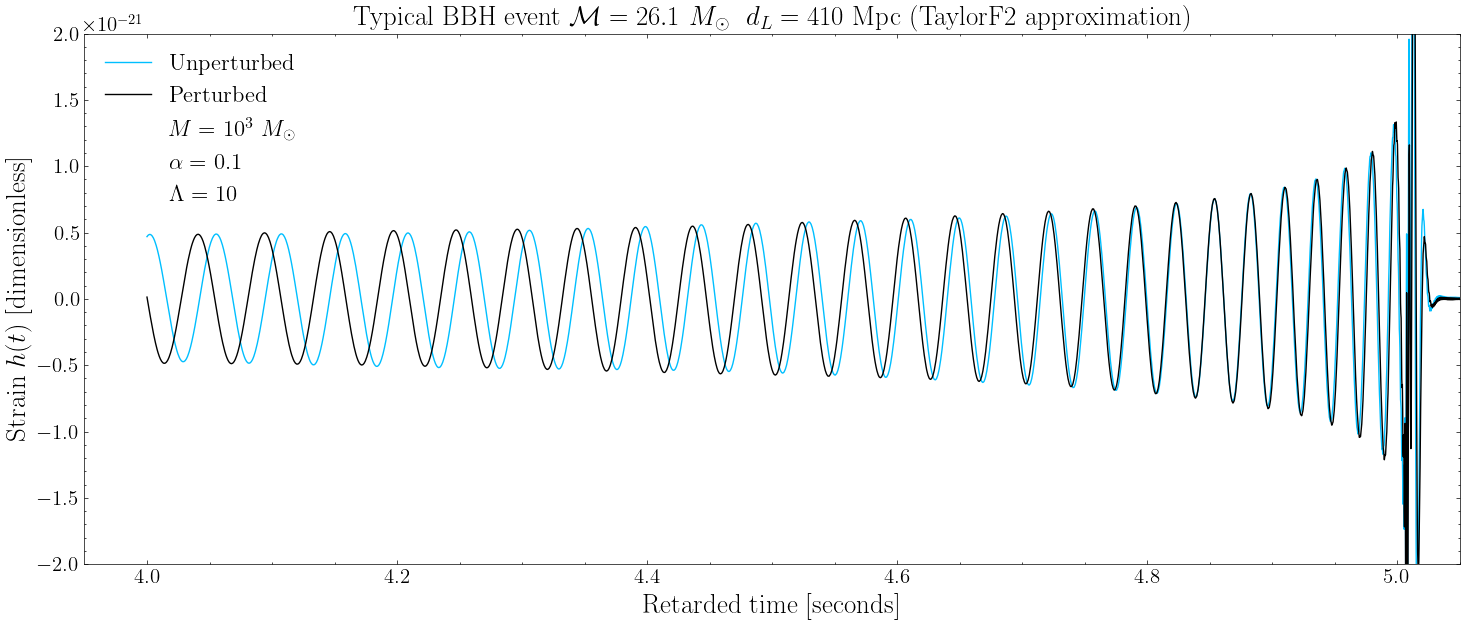

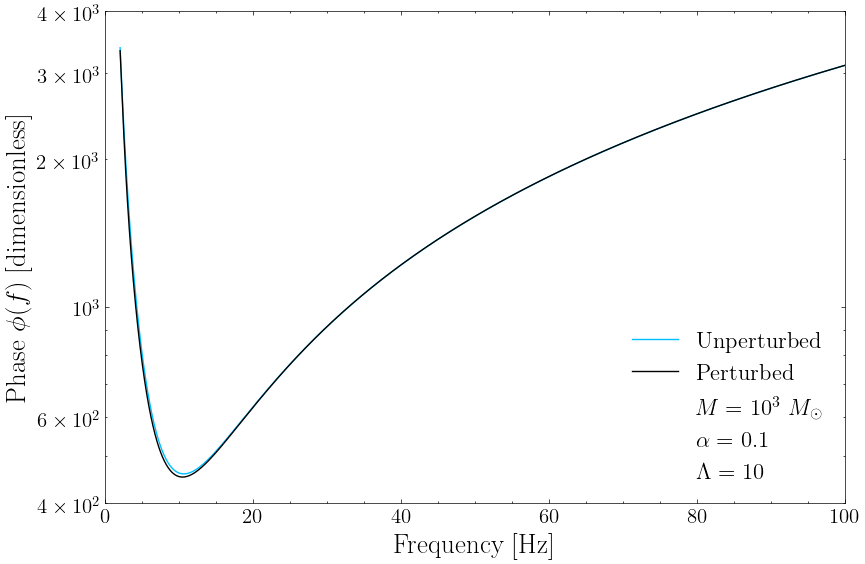

In [13]:
##############################  --------------------  Parameters of the problem --------------------    ##############################

# Gravitational wave signal (unperturbed)
Mchirp = 26.1165                           # chirp mass of the source  [solar masses]
eta    = 0.250                          # symmetric mass ratio of the source [dimensionless]
dL     = 0.41                           # luminosity distance of the GW source [Gpc]
dL_SI  = dL * 1e9 * pc                  # luminosity distance of the GW source [m] 

u_c      = 5                          # retarded time of coalescence [s]
phi_c    = 0                          # phase at coalescence [rad]


# Gravitational atom - uldm perturbation parameters
Lambda = 10                               # strength of coexistence [dimensionless]   (exaggerated for visualization - realistic is ~ 10^(-2))
alpha  = 0.1                             # gravitational fine structure constant [dimensionless]
M      = 1e3                             # mass of the central BH  [solar masses]
Theta  = 1                               # phase parameter of the perturbation [rad] 

aTilda  = 0.9                             # dimensionless spin of the central BH [dimensionless]
rErS    = 100                                # distance from the central BH to the source in units of schwarzschild radii [dimensionless]
theta_e = np.pi/2                         # polar angle of the source, spherical coordinates around the central BH [radians] 


############################## --------------------  Setup of the gravitational wave signal --------------------  ##############################

t_coal_s = - u_c                            # time of coalescence for gwfast [s]
Phi_coal = - phi_c - np.pi                   # phase at coalescence for gwfast [rad]

t_coal_days = t_coal_s/(24*3600)
event_parameters = {
    "Mc":       np.array([Mchirp]),              # chirp mass [M_sun]
    "eta":      np.array([eta]),                 # symmetric mass ratio η = m1*m2/(m1+m2)^2
    "chi1z":    np.array([0.0]),                 # dimensionless spin (BH 1, z-component)
    "chi2z":    np.array([0.0]),                 # dimensionless spin (BH 2, z-component)
    "dL":       np.array([dL]),                  # luminosity distance [Gpc]
    "theta":    np.array([0.0]),                 # polar angle [rad]
    "phi":      np.array([0.0]),                 # azimuthal angle [rad]
    "iota":     np.array([0.0]),                 # inclination angle [rad]
    "psi":      np.array([0.0]),                 # polarisation angle [rad]
    "tcoal":    np.array([t_coal_days]),  # time of coalescence [days]
    "Phicoal":  np.array([Phi_coal]),            # phase at coalescence [rad]
}


from gwfast import waveforms
wf = waveforms.TaylorF2_RestrictedPN()

# Frequency grid                         (important for the inverse FT, not so important if we stay in Fourier space)
fmin = 2                               # minimum frequency for the gwfast implementation [Hz]
fmax = 1000                             # maximum frequency for the gwfast implementation [Hz]
df   = 0.002                             # frequency resolution [Hz]   (sets total duration T = 1/df)
freqsVal = np.arange(fmin, fmax, df)


############################## -------------------- Setup of the gravitational wave detector --------------------  ##############################

import gwfast.signal as signal
import copy
import os
import gwfast.gwfastGlobals as glob

_psd_dir        = glob.detPath
_psd_o1         = os.path.join(_psd_dir, 'LVC_O1O2O3')
_psd_unofficial = os.path.join(_psd_dir, 'unofficial_curves_all_dets')
_psds = {
    'L1':   os.path.join(_psd_unofficial, 'aligo_design.txt'),       # aLIGO design sensitivity
}

_dets = copy.deepcopy(glob.detectors)
_common_= dict(
    wf_model       = wf,
    useEarthMotion = False,   # negligible for BBH; set True for BNS
    is_ASD         = True,    # all files above are ASDs
)

GWSignal_L1 = signal.GWSignal(
        **_common_,
        psd_path       = _psds['L1'],
        detector_shape = _dets['L1']['shape'],
        det_lat        = _dets['L1']['lat'],
        det_long       = _dets['L1']['long'],
        det_xax        = _dets['L1']['xax'],
        fmin           = 20.,  )


############################## --------------------    Condition for running the waveform: τ* ωδ < 33     -------------------- ##############################

tau_star_max = calculate_tau_star(fmin, Mchirp)   # [s]
omega_delta = calculate_omegaDelta211322(calculate_mu(alpha, M), alpha, aTilda) # [rad/s]
_1f2_condition = tau_star_max * omega_delta < 33   # [bool]

if not _1f2_condition:
    print('-------------------------------------------------------------------------------------------------------------------------------')
    print('Error: The condition τ* ωδ < 33 is not satisfied. The 1f2 function cannot be evaluated. Try increasing the minimum frequency.')
    print('-------------------------------------------------------------------------------------------------------------------------------')
    raise


############################## --------------------    Compute waveforms from gwfast     -------------------- ##############################

print("Setup completed -- Proceed to compute waveforms --")

# 1 -- Unperturbed waveforms

hFAmpl_unpert          = wf.Ampl(freqsVal, **event_parameters)             # amplitude A(f)
hFPhase_unpert         = GWSignal_L1.GWPhase(event_parameters, freqsVal)   # phase Φgwfast(f) = - ϕ(f)

time_unpert, ht_unpert = FT_to_time_waveform_no_tshift(freqsVal, hFAmpl_unpert, hFPhase_unpert)    # inverse FT to compute values of t and h(t) 
tau_unpert         = u_c - time_unpert     # τ time to coalescence (s)


# 2 -- Perturbed waveforms

# Relevant quantities of the gravitational atom
rS          = 2. * G*M*Msun /c**2   # Schwarzschild radius [m]
rVal        = rErS * rS                                                       # distance from central BH to source [m]
mu          = calculate_mu(alpha, M)                                    # mass of the ULB [eV]
Mcloud          = alpha * M                                                       # total mass of the cloud [solar masses]
rC          = rS / (2. * alpha**2)                                            # characteristic radius of the cloud [m]
omega_delta = calculate_omegaDelta211322(mu, alpha, aTilda)             # background oscillation frequency [rad/s]

# Connection between oscillating background and perturbed phase
tau = wf.tau_star(freqsVal, **event_parameters)
intPotentialdR = calculate_dr_VI(Mcloud, rVal, rC, theta_e)                          # radial derivative of the interaction potential [dimensionless]
UpsilonVal     = Lambda * np.abs(1. / (omega_delta /c) * intPotentialdR)  # Υ: magnitude of the Doppler modulation [dimensionless]
mod_eta        = calculate_modulation_eta(UpsilonVal, tau, omega_delta, Theta)

# Perturbed phase in Fourier space
phase_unpert = wf.Phi(freqsVal, **event_parameters)
phase_pert_waveform = phase_unpert - mod_eta * (phase_unpert + 2.*np.pi*freqsVal*tau - np.pi + np.pi*0.25)
phase_pert = 2.*np.pi*freqsVal*(t_coal_days*3600.*24.) - Phi_coal - phase_pert_waveform


hFAmpl_pert          = wf.Ampl(freqsVal, **event_parameters)             # amplitude A(f)
hFPhase_pert         = phase_pert                           # phase Φgwfast(f) = - ϕ(f)

time_pert, ht_pert = FT_to_time_waveform_no_tshift(freqsVal, hFAmpl_pert, hFPhase_pert)    # inverse FT to compute values of t and h(t) 
tau_pert         = u_c - time_pert     # τ time to coalescence (s)


# Outputs: time_unpert, tau_unpert, ht_unpert, freqsNum, hFAmpl_unpert, hFPhase_unpert and same for pert
#          time_pert, tau_pert, ht_pert, freqsNum, hFAmpl_pert, hFPhase_pert


############################## --------------------------------- Plots  ------------------------------- ##############################

# Mask outputs within a window
mask_type = 'tau'   # or 'time'
tauWindowMax  = 1.0    # [s]
tauWindowMin  = -0.1   # [s]
timeWindowMax = u_c + 0.05   # [s]
timeWindowMin = u_c - 1.05    # [s]
if mask_type == 'tau':
    mask_unpert     = (tau_unpert            >= tauWindowMin)  & (tau_unpert            <= tauWindowMax)
    mask_pert       = (tau_pert              >= tauWindowMin)  & (tau_pert              <= tauWindowMax)

elif mask_type == 'time':
    mask_unpert     = (time_unpert           >= timeWindowMin) & (time_unpert           <= timeWindowMax)
    mask_pert    = (time_pert          >= timeWindowMin) & (time_pert          <= timeWindowMax)
else:
    raise ValueError("mask_type must be 'tau' or 'time'")

# Apply masks: unperturbed waveform
ht_unpert_plot       = ht_unpert[mask_unpert]
tau_unpert_plot      = tau_unpert[mask_unpert]
time_unpert_plot     = time_unpert[mask_unpert]

# Apply masks: perturbed waveform
ht_pert_plot      = ht_pert[mask_pert]
tau_pert_plot     = tau_pert[mask_pert]
time_pert_plot    = time_pert[mask_pert]



# Plot waveforms h(t)
xValues = [time_unpert_plot, time_pert_plot]
yValues = [ht_unpert_plot, ht_pert_plot]
plotLabels = [r"Unperturbed", r"Perturbed"]
LineStyles = ['-', '-']
LineWidths = [1, 1]
xLines = []
colors = ["deepskyblue", "black"]
xLabel = r'Retarded time [seconds]'
yLabel = r'Strain $h(t)$ [dimensionless]'
xScale = 'linear'
yScale = 'linear'
textLabels = [r"$M = $ {} $M_\odot$".format(sci_notation(M)), r"$\alpha = $ {}".format(alpha), r"$\Lambda = $ {}".format(sci_notation(Lambda))]
titleLabel = r"Typical BBH event $\mathcal{{M}} = {:.1f} \ M_\odot \ \ d_L = {:.0f}$ Mpc  (TaylorF2 approximation)".format(Mchirp, dL * 1000)
xMin = u_c - 1.05
xMax = u_c + 0.05
yMin = -2e-21
yMax = 2e-21
save = False
saveName = "3 comparison [h(t)] gwfast.png"
xSizePlot = 2.5 * 1
ySizePlot = 1.1   * 1
xInv = False
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, LineWidths = LineWidths,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines, 
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName,
                xInv = xInv, xSizePlot = xSizePlot, ySizePlot = ySizePlot)



# Plot phase -ϕ(f)
xValues = [freqsVal, freqsVal]
yValues = [-hFPhase_unpert, -hFPhase_pert]
plotLabels = [r"Unperturbed", r"Perturbed"]
LineStyles = ['-', '-']
LineWidths = [1, 1]
xLines = []
colors = ["deepskyblue", "black"]
xLabel = r'Frequency [Hz]'
yLabel = r'Phase $\phi(f)$ [dimensionless]'
xScale = 'linear'
yScale = 'log'
textLabels = [r"$M = $ {} $M_\odot$".format(sci_notation(M)), r"$\alpha = $ {}".format(alpha), r"$\Lambda = $ {}".format(sci_notation(Lambda))]
titleLabel = ""
xMin = 0
xMax = 100
yMin = 4e2
yMax = 4e3
save = False
saveName = "3 comparison perturbed [phase(f)] gwfast.png"
xSizePlot = 1.5 * 1
ySizePlot = 1.0   * 1
xInv = False
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, LineWidths = LineWidths,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines, 
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName,
                xInv = xInv, xSizePlot = xSizePlot, ySizePlot = ySizePlot)





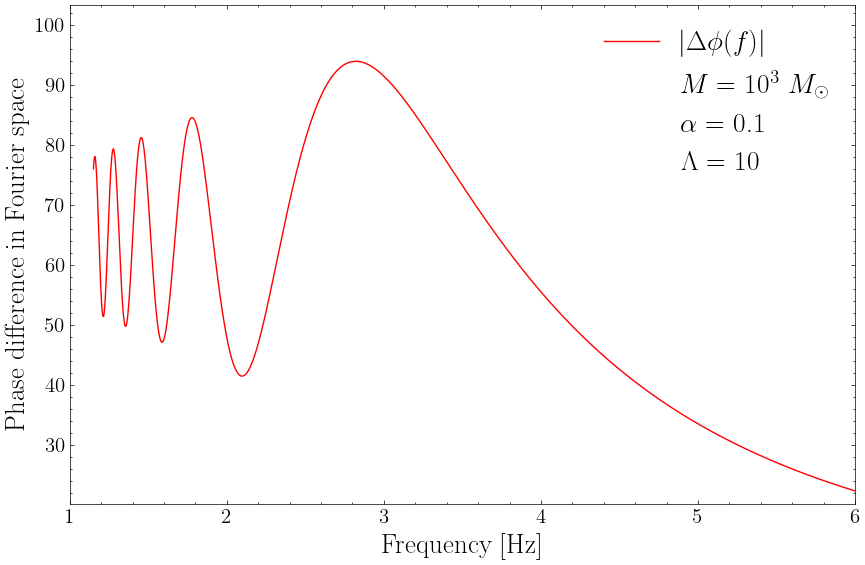

In [7]:
# Recompute using a larger frequency grid
fmin = 1.15                               # minimum frequency for the gwfast implementation [Hz]
fmax = 1000                             # maximum frequency for the gwfast implementation [Hz]
df   = 0.002                             # frequency resolution [Hz]   (sets total duration T = 1/df)
freqsVal = np.arange(fmin, fmax, df)

tau_star_max = calculate_tau_star(fmin, Mchirp)   # [s]
omega_delta = calculate_omegaDelta211322(calculate_mu(alpha, M), alpha, aTilda) # [rad/s]
_1f2_condition = tau_star_max * omega_delta < 33   # [bool]

if not _1f2_condition:
    print('-------------------------------------------------------------------------------------------------------------------------------')
    print('Error: The condition τ* ωδ < 33 is not satisfied. The 1f2 function cannot be evaluated. Try increasing the minimum frequency.')
    print('-------------------------------------------------------------------------------------------------------------------------------')
    raise

# Unperturbed phase
hFAmpl_unpert          = wf.Ampl(freqsVal, **event_parameters)             # amplitude A(f)
hFPhase_unpert         = GWSignal_L1.GWPhase(event_parameters, freqsVal)   # phase Φgwfast(f) = - ϕ(f)

time_unpert, ht_unpert = FT_to_time_waveform_no_tshift(freqsVal, hFAmpl_unpert, hFPhase_unpert)    # inverse FT to compute values of t and h(t) 
tau_unpert         = u_c - time_unpert     # τ time to coalescence (s)

tau = wf.tau_star(freqsVal, **event_parameters)
# Requires Mc, rVal, rC, rS from the setup cell above
intPotentialdR = calculate_dr_VI(Mcloud, rVal, rC, theta_e)                          # radial derivative of the interaction potential [dimensionless]
UpsilonVal     = Lambda * np.abs(1. / (omega_delta /c) * intPotentialdR)  # Υ: magnitude of the Doppler modulation [dimensionless]
mod_eta        = calculate_modulation_eta(UpsilonVal, tau, omega_delta, Theta)

# Perturbed phase in Fourier space
phase_unpert = wf.Phi(freqsVal, **event_parameters)
phase_pert_waveform = phase_unpert - mod_eta * (phase_unpert + 2.*np.pi*freqsVal*tau - np.pi + np.pi*0.25)
phase_pert = 2.*np.pi*freqsVal*(t_coal_days*3600.*24.) - Phi_coal - phase_pert_waveform


hFAmpl_pert          = wf.Ampl(freqsVal, **event_parameters)             # amplitude A(f)
hFPhase_pert         = phase_pert                           # phase Φgwfast(f) = - ϕ(f)

time_pert, ht_pert = FT_to_time_waveform_no_tshift(freqsVal, hFAmpl_pert, hFPhase_pert)    # inverse FT to compute values of t and h(t) 
tau_pert         = u_c - time_pert     # τ time to coalescence (s)


    
# Plot phase |Δϕ(f)|
xValues = [freqsVal]
yValues = [np.abs(hFPhase_unpert - hFPhase_pert)]
plotLabels = [r"$|\Delta \phi(f)|$"]
LineStyles = ['-']
LineWidths = [1]
xLines = []
colors = ["red"]
xLabel = r'Frequency [Hz]'
yLabel = r'Phase difference in Fourier space'
xScale = 'linear'
yScale = 'linear'
textLabels = [r"$M = $ {} $M_\odot$".format(sci_notation(M)), r"$\alpha = $ {}".format(alpha), r"$\Lambda = $ {}".format(sci_notation(Lambda))]
titleLabel = ""
xMin = 1
xMax = 6

plot_mask = np.logical_and(freqsVal > xMin, freqsVal < xMax)
yValues_masked = np.abs(hFPhase_unpert - hFPhase_pert)[plot_mask]

yMin = np.min(yValues_masked * 0.9)
yMax = np.max(yValues_masked * 1.1)
save = False
saveName = "3 comparison perturbed [Delta phase(f)] gwfast.png"
xSizePlot = 1.5 * 1
ySizePlot = 1.0   * 1
xInv = False
legendSize = 1.2
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, LineWidths = LineWidths,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines, 
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName,
                xInv = xInv, xSizePlot = xSizePlot, ySizePlot = ySizePlot, legendSize = legendSize)
